# 04 — Indicateurs de performance du pipeline

**Livrable n°6** — Benoit Girard

Les KPI répondent à trois questions : la donnée est-elle **bonne**, le pipeline est-il **rapide et économe**, et le jeu de données **progresse-t-il** ? Le tableau de bord interactif correspondant est `dashboard/app.py`.

In [1]:
import sys
from pathlib import Path

RACINE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RACINE / "src"))

from dotenv import load_dotenv

load_dotenv(RACINE / ".env")

from multimodal_etl.logging_setup import setup_logging

setup_logging()

## 1. Charger les artefacts de la dernière exécution

Trois éléments : le jeu de données, ses statistiques de transformation, et la fiche de la dernière exécution.

In [2]:
from multimodal_etl.kpi import charge_dernier_dataset, compute_kpis

df, stats, run = charge_dernier_dataset()
print(
    f"{len(df)} publications, exécution du {run.get('run_at', '?')} "
    f"({run.get('orchestrateur', '?')})"
)
kpis = compute_kpis(df, stats, run)

131 publications, exécution du 2026-08-20T10:00:32+00:00 (script)


## 2. Qualité de la donnée

Le taux d'association texte-image est le plus important : c'est la définition même du jeu de données. Le taux de publications datées compte aussi — sans date, pas de mesure de fraîcheur possible.

In [3]:
kpis["qualite"]

{'taux_validite_pct': 73.2,
 'taux_association_texte_image_pct': 100.0,
 'taux_labellise_pct': 20.6,
 'taux_doublons_pct': 0.0,
 'taux_date_connue_pct': 94.7,
 'longueur_texte_moyenne': 300.4}

## 3. Volume et diversité

La part de la source dominante mérite une explication : un jeu de données capté à 80 % par un seul éditeur transmet son biais éditorial au modèle. On surveille donc la concentration, pas seulement le volume.

In [4]:
kpis["volume"]

{'nb_publications': 131,
 'nb_sources': 7,
 'part_source_dominante_pct': 34.4,
 'repartition_sources': {'rss:the_guardian': 45,
  'rss:bbc_news': 27,
  'rss:abc_news': 25,
  'fakeddit:fakenews': 10,
  'fakeddit:news': 10,
  'newsdata': 7,
  'fakenewsnet:gossipcop': 7},
 'repartition_langues': {'en': 131},
 'repartition_methodes_acces': {'flux_rss': 97,
  'telechargement_kaggle': 20,
  'api_rest': 7,
  'telechargement_github': 7}}

## 4. Fraîcheur

Un détecteur de fake news doit voir l'actualité récente. Si l'âge médian grimpe, c'est que le flux s'est figé et qu'on ré-ingère du passé.

In [5]:
kpis["fraicheur"]

{'age_median_heures': 16.4,
 'part_moins_24h_pct': 64.5,
 'publications_datees': 124}

## 5. Performance et coût

La rapidité (durée par étape, débit), le coût (appels d'API consommés sur le quota, disque occupé par les images) et l'apport réel de l'exécution.

In [6]:
kpis["performance"]

{'duree_extraction_sec': 58.81,
 'duree_transformation_sec': 0.38,
 'duree_chargement_sec': 0.33,
 'duree_totale_sec': 59.52,
 'debit_publications_par_sec': 3.0,
 'appels_api_consommes': 1,
 'poids_images_mo': 10.8,
 'taux_images_telechargees_pct': 92.3,
 'taux_nouveaute_pct': 7.8,
 'publications_ajoutees': 14,
 'publications_en_base': 139,
 'failed_sources': 0}

## 6. Confrontation aux seuils

Les seuils sont définis dans `multimodal_etl.kpi.SEUILS`, avec la justification de chacun. Le plan de monitoring et le tableau de bord lisent le même dictionnaire : le document ne peut pas se désynchroniser de l'application.

In [7]:
import pandas as pd

from multimodal_etl.kpi import evalue_seuils

pd.DataFrame(evalue_seuils(kpis))[["libelle", "valeur", "attendu", "statut", "justification"]]

,libelle,valeur,attendu,statut,justification
0,Taux de validité,73.20,≥ 60,vert,Calé sur le comportement observé (environ 65 %...
1,Association texte-image,100.00,≥ 90,vert,C'est la définition même du jeu de données : s...
2,Taux de doublons,0.00,≤ 5,vert,Un taux qui grimpe signale une sur-ingestion o...
3,Volume ingéré,131.00,≥ 80,vert,Un volume qui s'effondre trahit une source en ...
4,Part de la source dominante,34.40,≤ 50,vert,Un jeu de données capté par une seule source t...
5,Âge médian,16.40,≤ 48,vert,Un détecteur de fake news doit voir l'actualit...
6,Durée totale,59.52,≤ 90,vert,"Au-delà, la fenêtre d'exécution quotidienne fi..."
7,Images téléchargées,92.30,≥ 80,vert,Mesure la disponibilité des médias : une URL a...
8,Sources en échec,0.00,≤ 0,vert,"Deux sources muettes le même jour, c'est un in..."


## 7. Visualisations

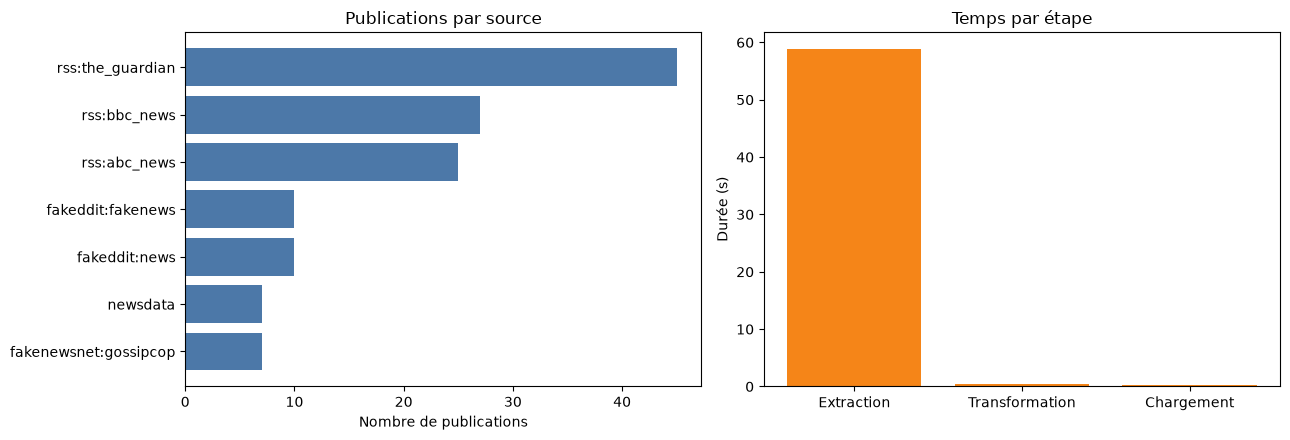

In [8]:
import matplotlib.pyplot as plt

repartition = kpis["volume"]["repartition_sources"]
figure, (gauche, droite) = plt.subplots(1, 2, figsize=(13, 4.5))

gauche.barh(list(repartition.keys())[::-1], list(repartition.values())[::-1], color="#4C78A8")
gauche.set_title("Publications par source")
gauche.set_xlabel("Nombre de publications")

etapes = ["Extraction", "Transformation", "Chargement"]
durees = [
    kpis["performance"]["duree_extraction_sec"],
    kpis["performance"]["duree_transformation_sec"],
    kpis["performance"]["duree_chargement_sec"],
]
droite.bar(etapes, durees, color="#F58518")
droite.set_title("Temps par étape")
droite.set_ylabel("Durée (s)")

plt.tight_layout()
plt.show()

## 8. Historique des exécutions

Une valeur isolée se lit mal : un taux de validité de 80 % n'a pas le même sens selon qu'il monte ou qu'il descend. C'est la tendance qui déclenche une action.

In [9]:
from multimodal_etl.kpi import historique_runs

historique = historique_runs()
historique[
    [
        "date",
        "orchestrateur",
        "publications_extraites",
        "publications_ajoutees",
        "publications_en_base",
        "duree_totale_sec",
        "taux_validite_pct",
    ]
]

,date,orchestrateur,publications_extraites,publications_ajoutees,publications_en_base,duree_totale_sec,taux_validite_pct
0,2026-08-20 09:59:20+00:00,script,179,125,125,61.06,69.8
1,2026-08-20 10:00:32+00:00,script,179,14,139,59.52,72.6


Le nombre de publications ajoutées décroît d'une exécution à l'autre alors que le total en base augmente : le chargement est **incrémental**, seules les publications encore inconnues sont écrites. C'est exactement le comportement attendu d'une ingestion quotidienne.